In [8]:
from IPython.display import HTML
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.ndimage import distance_transform_edt, zoom
import torch
from typing import List, Tuple

SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Environment Generation

In [9]:
WORLD_SIZE: Tuple[int, int] = (1000, 1000)
START_POSITION: Tuple[int, int] = (1, 1)
END_POSITION: Tuple[int, int] = (999, 999)
PATH_COST: float = 1.0
NUM_SPLINE_SAMPLES: int = 10000
NUM_SPLINE_INTERPOLATIONS: int = 100
SPLINE_POINTS_BEGINNING: List[Tuple[int, int]] = [
    START_POSITION,
    (200, 200),
    (200, 400),
    (500, 500),
    (800, 600),
    (800, 800),
    END_POSITION
]
SPLINE_POINTS_END: List[Tuple[int, int]] = [
    START_POSITION,
    (200, 900),
    (200, 750),
    (500, 500),
    (800, 250),
    (800, 100),
    END_POSITION
]
NUM_SPATIAL_SAMPLES: int = 10000

In [10]:
def create_spline(points: List[Tuple[int, int]], num_samples: int) -> np.ndarray:
    x_points = [p[0] for p in points]
    y_points = [p[1] for p in points]

    cs = CubicSpline(
        np.linspace(0, 1, len(x_points)),
        np.vstack([x_points, y_points]), axis=1
    )
    t = np.linspace(0, 1, num_samples)
    spline_points = cs(t).T
    return spline_points

def create_costmap(world: np.ndarray, spline_points: np.ndarray, path_cost: float) -> np.ndarray:
    costmap = np.zeros(world.shape)
    for point in spline_points:
        x, y = int(point[0]), int(point[1])
        if 0 <= x < world.shape[0] and 0 <= y < world.shape[1]:
            costmap[x, y] = path_cost

    path_mask = (costmap == path_cost)
    distances = distance_transform_edt(~path_mask)
    costmap = 1 + distances
    return costmap

def plot_costmaps(
        costmaps: List[np.ndarray],
        start_position: np.ndarray,
        end_position: np.ndarray,
        titles: List[str] = None
    ):

    if titles is None:
        titles = ['Costmap'] * len(costmaps)

    fig, axes = plt.subplots(1, len(costmaps), figsize=(10, 5))
    for ax, costmap, title in zip(axes, costmaps, titles):
        ax.imshow(costmap, cmap='viridis', interpolation='nearest', origin='lower')
        ax.plot(*start_position[::-1], 'g', marker="X")  # Start position
        ax.plot(*end_position[::-1], 'r', marker="X")    # End position
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# create a discretized version of the cost maps
def create_discretized_costmaps(cost_maps: List[np.ndarray], num_samples: int) -> List[np.ndarray]:
    """
    convert the continuous valued cost maps into a discretized version
    """
    discretized_maps = []
    for cost_map in cost_maps:
        normalized_map = (cost_map - cost_map.min()) / (cost_map.max() - cost_map.min())
        # Create a new map with the same shape but discretized values
        discretized_map = np.digitize(normalized_map, bins=np.linspace(0, 1, num_samples))
        discretized_maps.append(discretized_map)
    return discretized_maps

def animate_costmaps(
    costmaps: List[np.ndarray],
    start_position: np.ndarray,
    end_position: np.ndarray,
    titles: List[str] = None,
    interval: int = 20,  # milliseconds between frames
    save_path: str = None  # optional: path to save the animation
):
    if titles is None:
        titles = ['Costmap'] * len(costmaps)

    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Initialize the first frame
    im = ax.imshow(
        costmaps[0],
        cmap='viridis',
        interpolation='nearest',
        origin='lower'
    )
    start_marker, = ax.plot(
        *start_position[::-1],
        'g',
        marker="X",
        markersize=10
    )
    end_marker, = ax.plot(
        *end_position[::-1],
        'r',
        marker="X",
        markersize=10
    )
    title_text = ax.set_title(titles[0])
    ax.axis('off')

    def update(frame):
        im.set_data(costmaps[frame])
        title_text.set_text(titles[frame])
        return [im, title_text, start_marker, end_marker]

    ani = animation.FuncAnimation(
        fig, update, frames=len(costmaps), interval=interval, blit=True
    )

    if save_path is not None:
        ani.save(save_path, writer='ffmpeg', dpi=150)

    plt.close(fig)  # Close the figure to avoid displaying it inline

    return ani

In [11]:
world = np.zeros(WORLD_SIZE)
start_costmap = create_costmap(
    world,
    create_spline(SPLINE_POINTS_BEGINNING, NUM_SPLINE_SAMPLES),
    PATH_COST
)
end_costmap = create_costmap(
    world,
    create_spline(SPLINE_POINTS_END, NUM_SPLINE_SAMPLES),
    PATH_COST
)

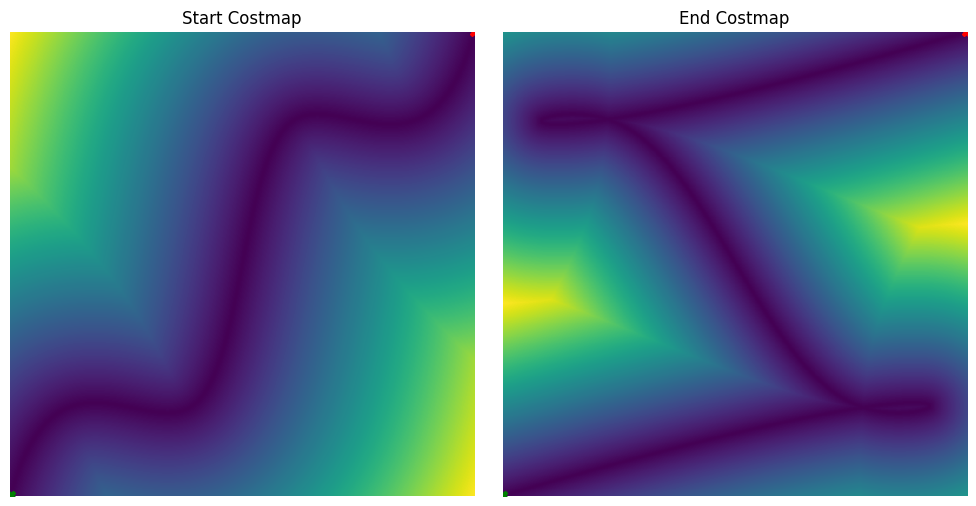

In [12]:
plot_costmaps(
    [start_costmap, end_costmap],
    START_POSITION,
    END_POSITION,
    titles=["Start Costmap", "End Costmap"]
)

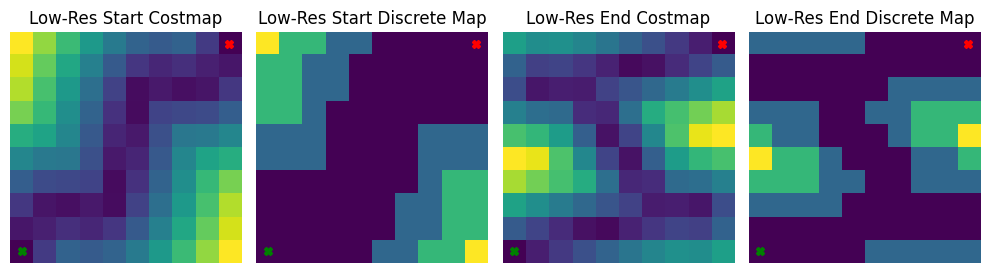

In [13]:
downscale_factor = 0.01
low_res_start_costmap = zoom(start_costmap, downscale_factor, order=1)
low_res_end_costmap = zoom(end_costmap, downscale_factor, order=1)

low_res_start_pos = ((START_POSITION[0]) - 1, (START_POSITION[1])-1)
low_res_end_pos = ((END_POSITION[0] * downscale_factor) - 1, (END_POSITION[1] * downscale_factor)-1)

num_bins = 4

discrete_maps = create_discretized_costmaps([low_res_start_costmap, low_res_end_costmap], num_bins)

plot_costmaps(
    [low_res_start_costmap, discrete_maps[0], low_res_end_costmap, discrete_maps[1]],
    low_res_start_pos,
    low_res_end_pos,
    titles=["Low-Res Start Costmap", "Low-Res Start Discrete Map", "Low-Res End Costmap", "Low-Res End Discrete Map"]
)

## Data Generation

In [14]:
def convert_costmap_to_points(costmap: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a costmap to a set of points sampled according to the cost distribution.
    """
    # Get coordinates
    x_indices, y_indices = np.meshgrid(
        np.arange(costmap.shape[1]),  # x = columns
        np.arange(costmap.shape[0])   # y = rows
    )

    # Flatten to a list of (x, y) points
    points = np.stack([x_indices.ravel(), y_indices.ravel()], axis=-1)

    # Flatten the costmap values
    labels = costmap.ravel()

    # Subtract 1 from all labels to ensure they are zero-indexed
    labels -= 1
    return points, labels